In [23]:
import pickle
from dython.nominal import associations
from sklearn.svm import LinearSVR
import matplotlib.pyplot as plt
import numpy as np
from numpy import load
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.utils import shuffle
from IPython.display import display

In [24]:
with open('X.pickle', 'rb') as handle:
    load_X = pickle.load(handle)

with open('Y.pickle', 'rb') as handle:
    load_Y = pickle.load(handle)

X = pd.DataFrame(load_X, columns=["i", "j", "R_ij", "bond_order", "1st_nei"])
y = pd.DataFrame(load_Y)

   i  j      R_ij  bond_order 1st_nei
0  C  C  0.151457           1   CHHHO
1  C  C  0.153065           1   CCCHO
2  O  C  0.122295           2      CC
3  H  C  0.109654           1     CHH
4  H  C  0.109250           1     CHH


<Axes: ylabel='Frequency'>

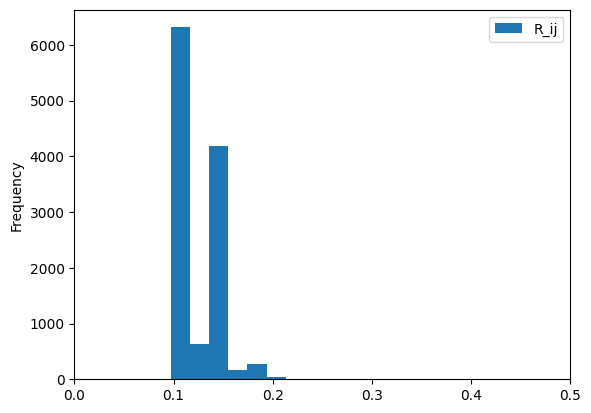

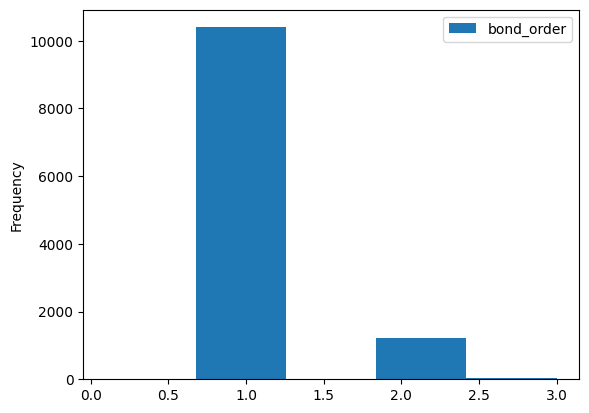

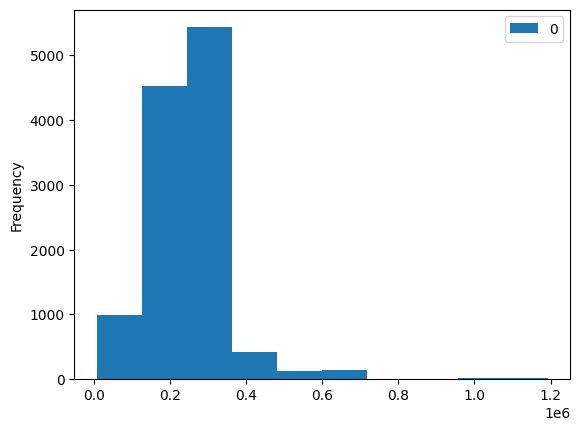

In [25]:
print(X.head())
X.plot.hist(column="R_ij", bins=150, xlim=(0,0.5))
X.plot.hist(column="bond_order", bins=5)
y.plot.hist()


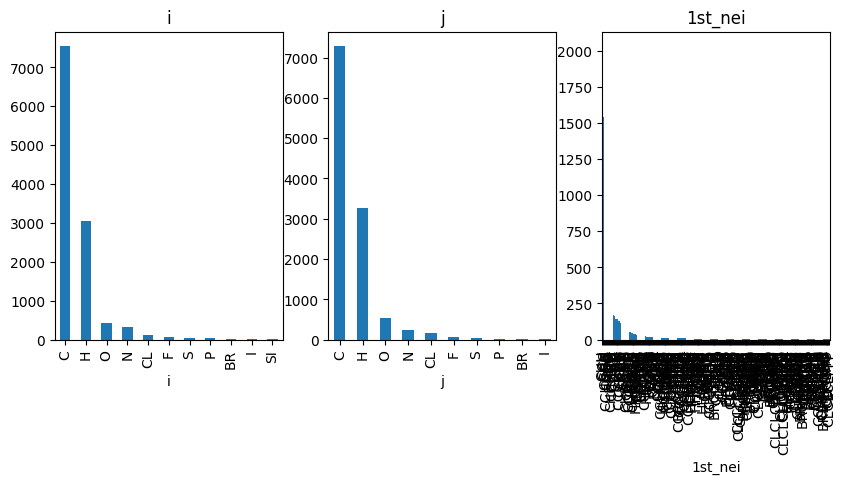

In [26]:
cat_features = ['i', 'j', '1st_nei']
fig, ax = plt.subplots(1, len(cat_features), figsize=(10,4))

for i, cat_feature in enumerate(X[cat_features]):
    X[cat_feature].value_counts().plot(kind="bar",
                                          title=cat_feature, 
                                          ax=ax[i], )

/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:736: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[i], columns[j]] = _inf_nan_str(ij)
/home/yaofu/miniconda3/lib/python3.11/site-packages/dython/nominal.py:737: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  inf_nan.loc[columns[j], columns[i]] = _inf_nan_str(ji)


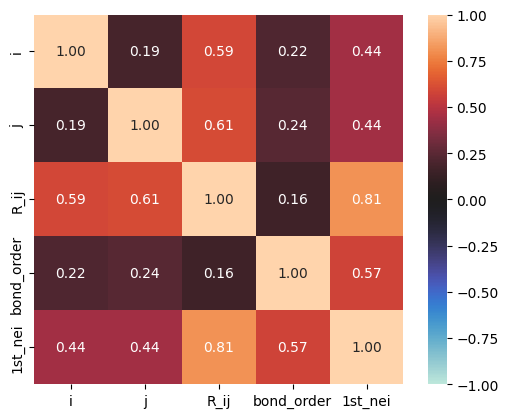

In [27]:
complete_correlation= associations(X)

In [28]:
def one_hot_encode_column(df: pd.DataFrame, col: int, pref: str = None) -> pd.DataFrame:
    encoded_column = pd.get_dummies(df[col], prefix=pref)
    df.drop(col, axis=1, inplace=True)
    # try:
    df = df.join(encoded_column)
    # except ValueError as verr:
    #     if "overlap" in verr.__str__():
    #         df = df.merge(encoded_column, left_on="BR", right_on="BR")

    return df

In [29]:
X = one_hot_encode_column(X, "i", "i")
X = one_hot_encode_column(X, "j", "j")
X = one_hot_encode_column(X, "1st_nei", "nei")

X.columns = X.columns.map(str)


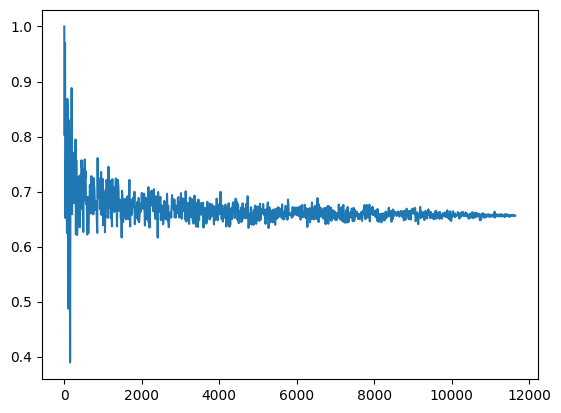

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

N = len(X)

#idx = 0
test_scores =[]
train_scores =[]
train_size = []
for i in range(5, N, 10):
    X_shuf, y_shuf = shuffle(X, y)
    #print(idx)
    Xnew_train = X_shuf[:i]
    Xnew_test = X[i:]
    ynew_train = y_shuf[:i]
    # print(np.max(ynew_train))
    # ynew_test = y[i:]
    model = LinearRegression()
    reg = model.fit(Xnew_train, ynew_train)
    ytrain_predict = reg.predict(Xnew_train)
    #score_train = mean_squared_error(ynew_train, ytrain_predict)
    score_train = r2_score(ynew_train, ytrain_predict)
    # train_scores.append(reg.score(Xnew_train, ynew_train))
    # test_scores.append(reg.score(Xnew_test, ynew_test))
    train_scores.append(score_train)
    train_size.append(i)
    #idx += 1
plt.plot(train_size, train_scores)

In [31]:
X.head()

,R_ij,bond_order,i_BR,i_C,i_CL,i_F,i_H,i_I,i_N,i_O,...,nei_HOO,nei_HOOS,nei_NN,nei_NNO,nei_NO,nei_O,nei_OO,nei_OOO,nei_OOS,nei_P
0,0.151457,1,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.153065,1,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.122295,2,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,0.109654,1,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.109250,1,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
